In [311]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [312]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
# from saqc import SaQC
import metpyqc as qc

from qc_func import *
from fake_data_design import *
from visualizaion_func import *

In [313]:
from crmprtd import setup_logging
import sqlalchemy as sa
from sqlalchemy.orm import Session
import sys
function_path = '../'
sys.path.append(function_path)

save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
log_file_path = save_path

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)

session

#### Find the stations under network 2, and have all the variables I want

In [314]:
sql_text = sa.text("""
SELECT s.station_id, h.station_name
FROM meta_history h
JOIN meta_station s
    ON h.station_id = s.station_id
WHERE s.network_id = 2

AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'MINIMUM_AIR_TEMPERATURE'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'MAXIMUM_AIR_TEMPERATURE'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'min_air_temp_snc_last_reset'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'max_air_temp_snc_last_reset'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'air_temp'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'HOURLY_PRECIPITATION'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'snwfl_amt_pst1hr'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'snw_dpth'
)
;

""")

with engine.begin() as conn:
    df = pd.read_sql(sql_text, conn)

df

,station_id,station_name
0,2668,Nicolum Creek
1,2794,Nordic 2
2,2955,North Courtenay
3,2902,Onion Lake
4,2764,Paulson Summit
...,...,...
99,2834,West Twin Creek
100,2870,Enterprise
101,2891,Endgoal
102,2906,Salvus


In [315]:
stations_2 = df['station_id'].head(2).tolist()

sql_text = sa.text("""
SELECT s.station_id, o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 2
AND s.station_id IN :stations
AND v.net_var_name IN (
    'MINIMUM_AIR_TEMPERATURE',
    'MAXIMUM_AIR_TEMPERATURE',
    'min_air_temp_snc_last_reset',
    'max_air_temp_snc_last_reset',
    'air_temp',
    'HOURLY_PRECIPITATION',
    'snwfl_amt_pst1hr',
    'snw_dpth'
)
ORDER BY s.station_id, o.obs_time
""")

with engine.begin() as conn:
    df_obs = pd.read_sql(sql_text, conn, params={
                         "stations": tuple(stations_2)})

In [316]:
df_obs

,station_id,obs_time,net_var_name,datum
0,2668,2002-08-19 15:00:00,HOURLY_PRECIPITATION,0.0
1,2668,2002-08-19 16:00:00,HOURLY_PRECIPITATION,0.0
2,2668,2002-08-19 17:00:00,HOURLY_PRECIPITATION,0.0
3,2668,2002-08-19 18:00:00,HOURLY_PRECIPITATION,0.0
4,2668,2002-08-19 19:00:00,HOURLY_PRECIPITATION,0.0
...,...,...,...,...
989174,2794,2026-04-27 08:00:00,air_temp,1.0
989175,2794,2026-04-27 08:00:00,max_air_temp_snc_last_reset,1.0
989176,2794,2026-04-27 08:00:00,snwfl_amt_pst1hr,0.0
989177,2794,2026-04-27 08:00:00,snw_dpth,26.0


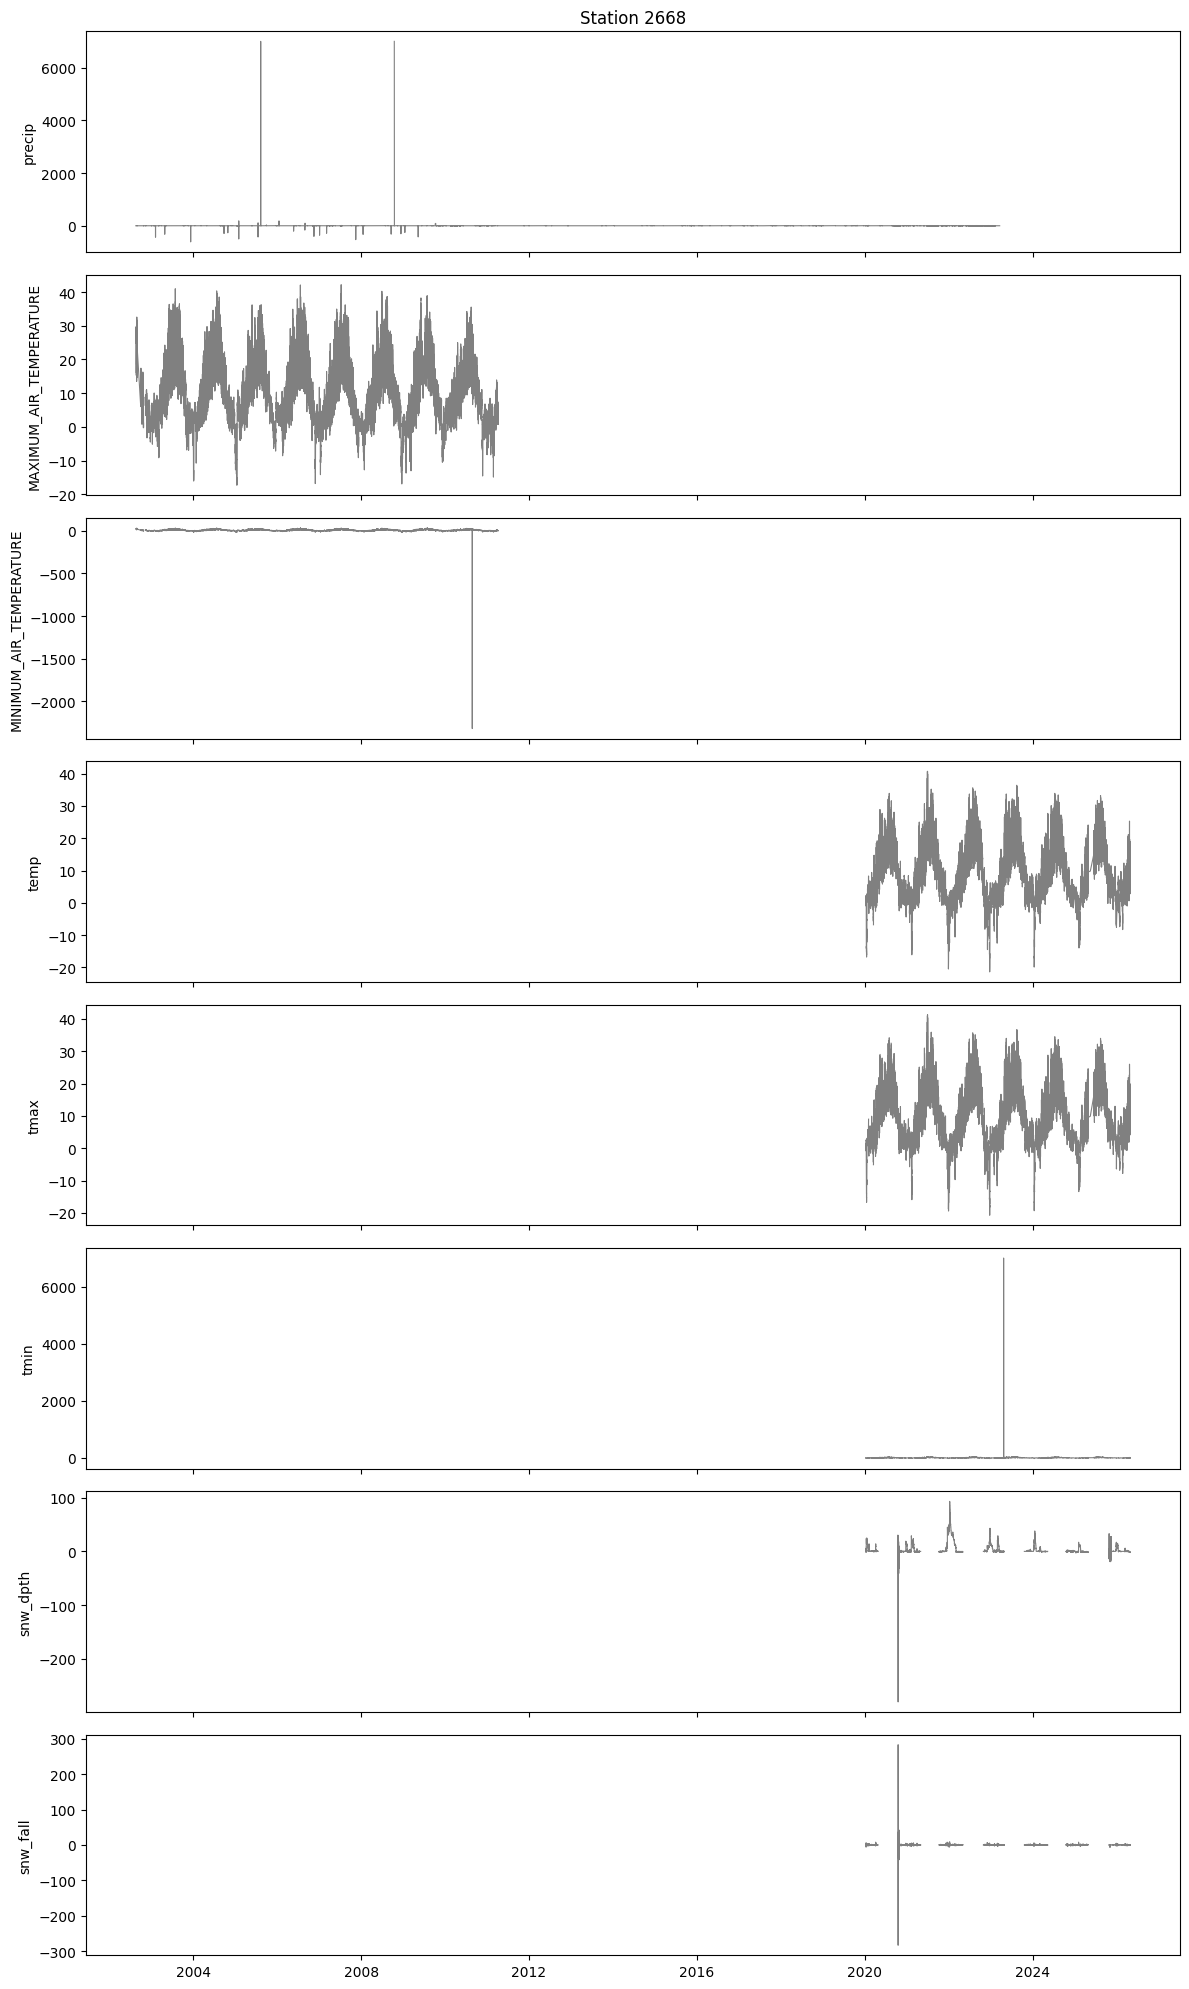

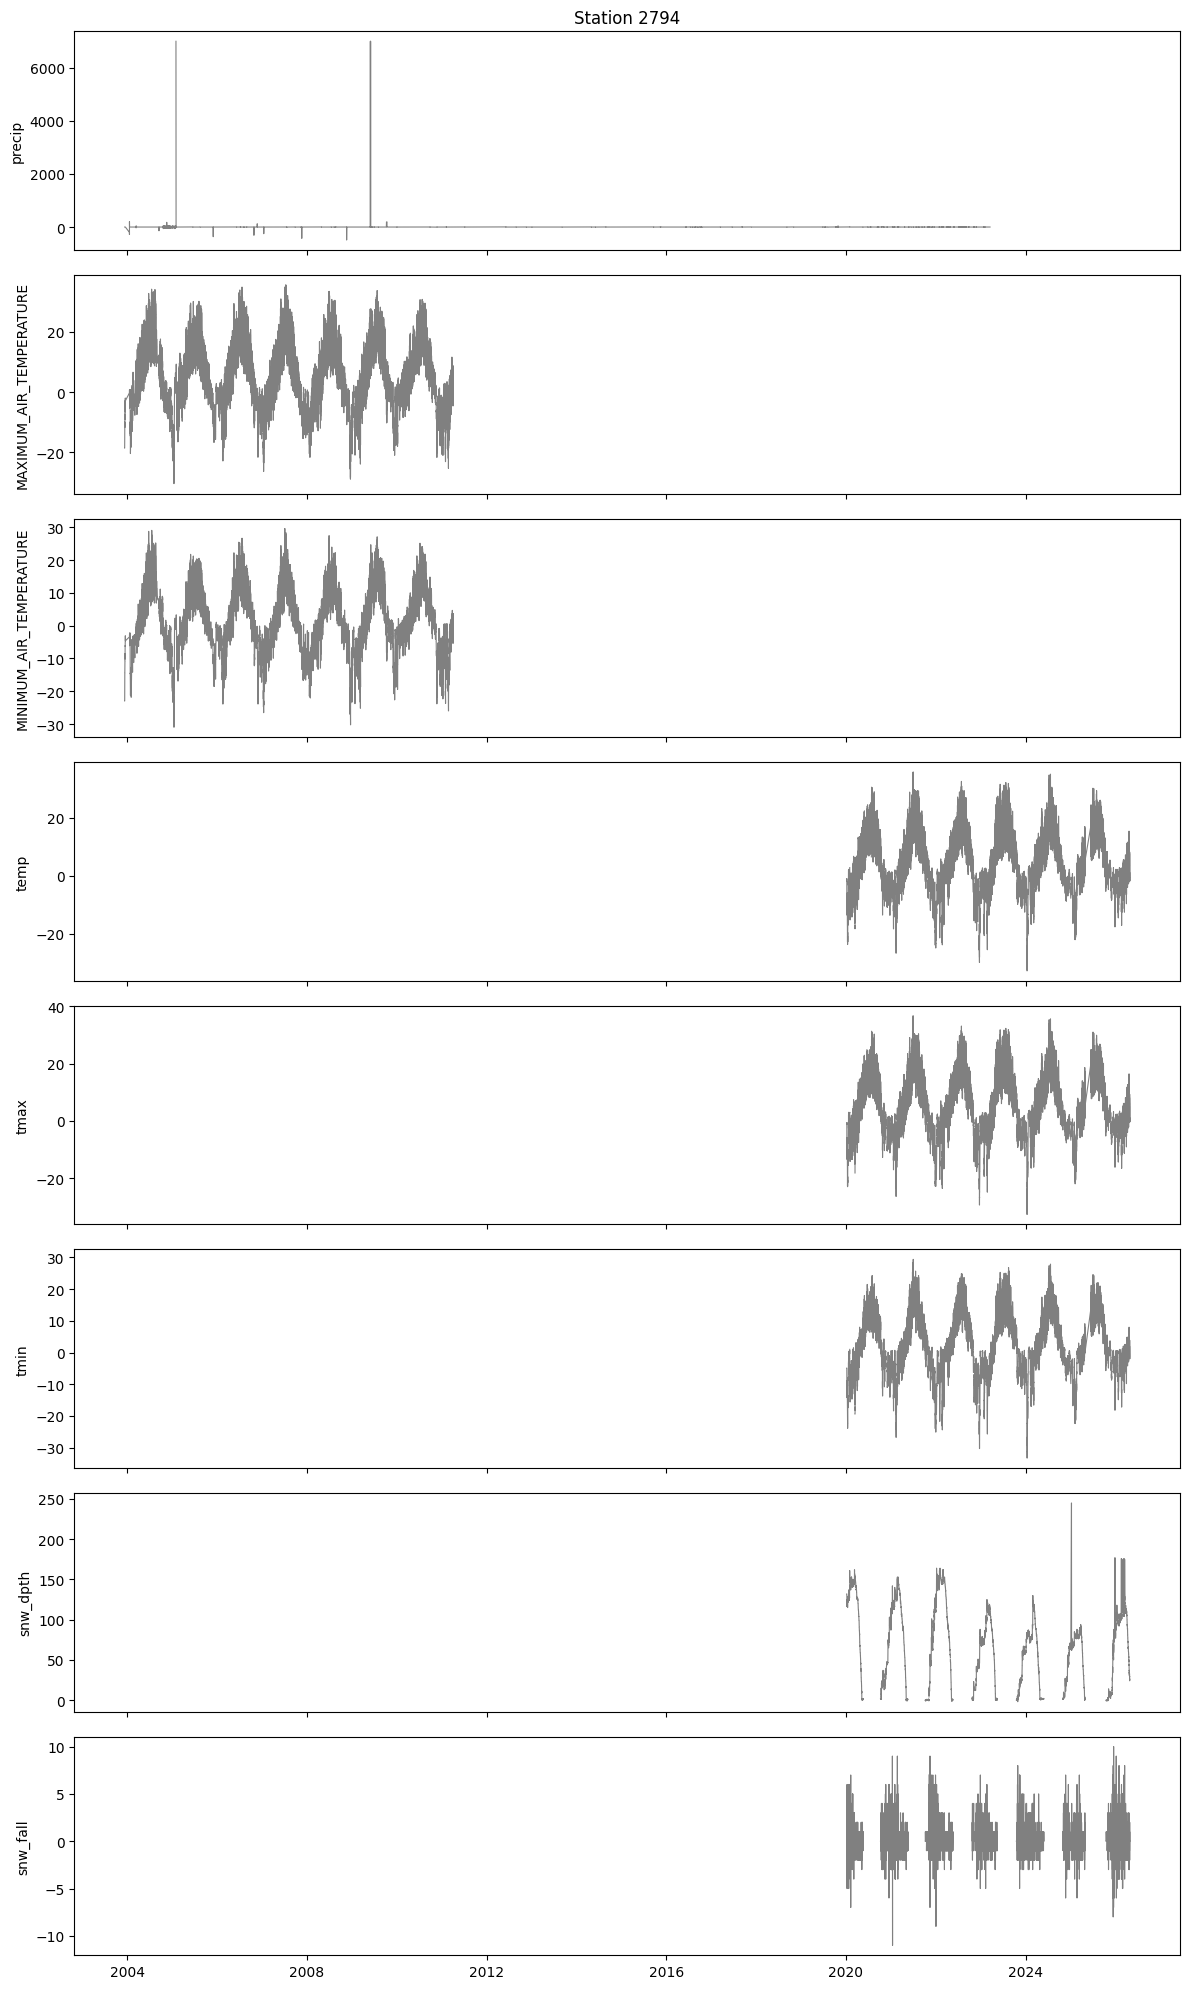

In [317]:
df_sql_list = []

for station_id, df_station in df_obs.groupby("station_id"):

    df_station = df_station.copy()
    df_station["obs_time"] = pd.to_datetime(df_station["obs_time"])

    df_sql = df_station.pivot_table(
        index="obs_time",
        columns="net_var_name",
        values="datum"
    ).sort_index()

    df_sql = df_sql.rename(columns={
        "min_air_temp_snc_last_reset": "tmin",
        "max_air_temp_snc_last_reset": "tmax",
        "air_temp": "temp",
        "HOURLY_PRECIPITATION": "precip",
        "snwfl_amt_pst1hr": "snw_fall"
    })

    df_sql_list.append((station_id, df_sql))

    plot_weather_data(df_sql, title=f"Station {station_id}")

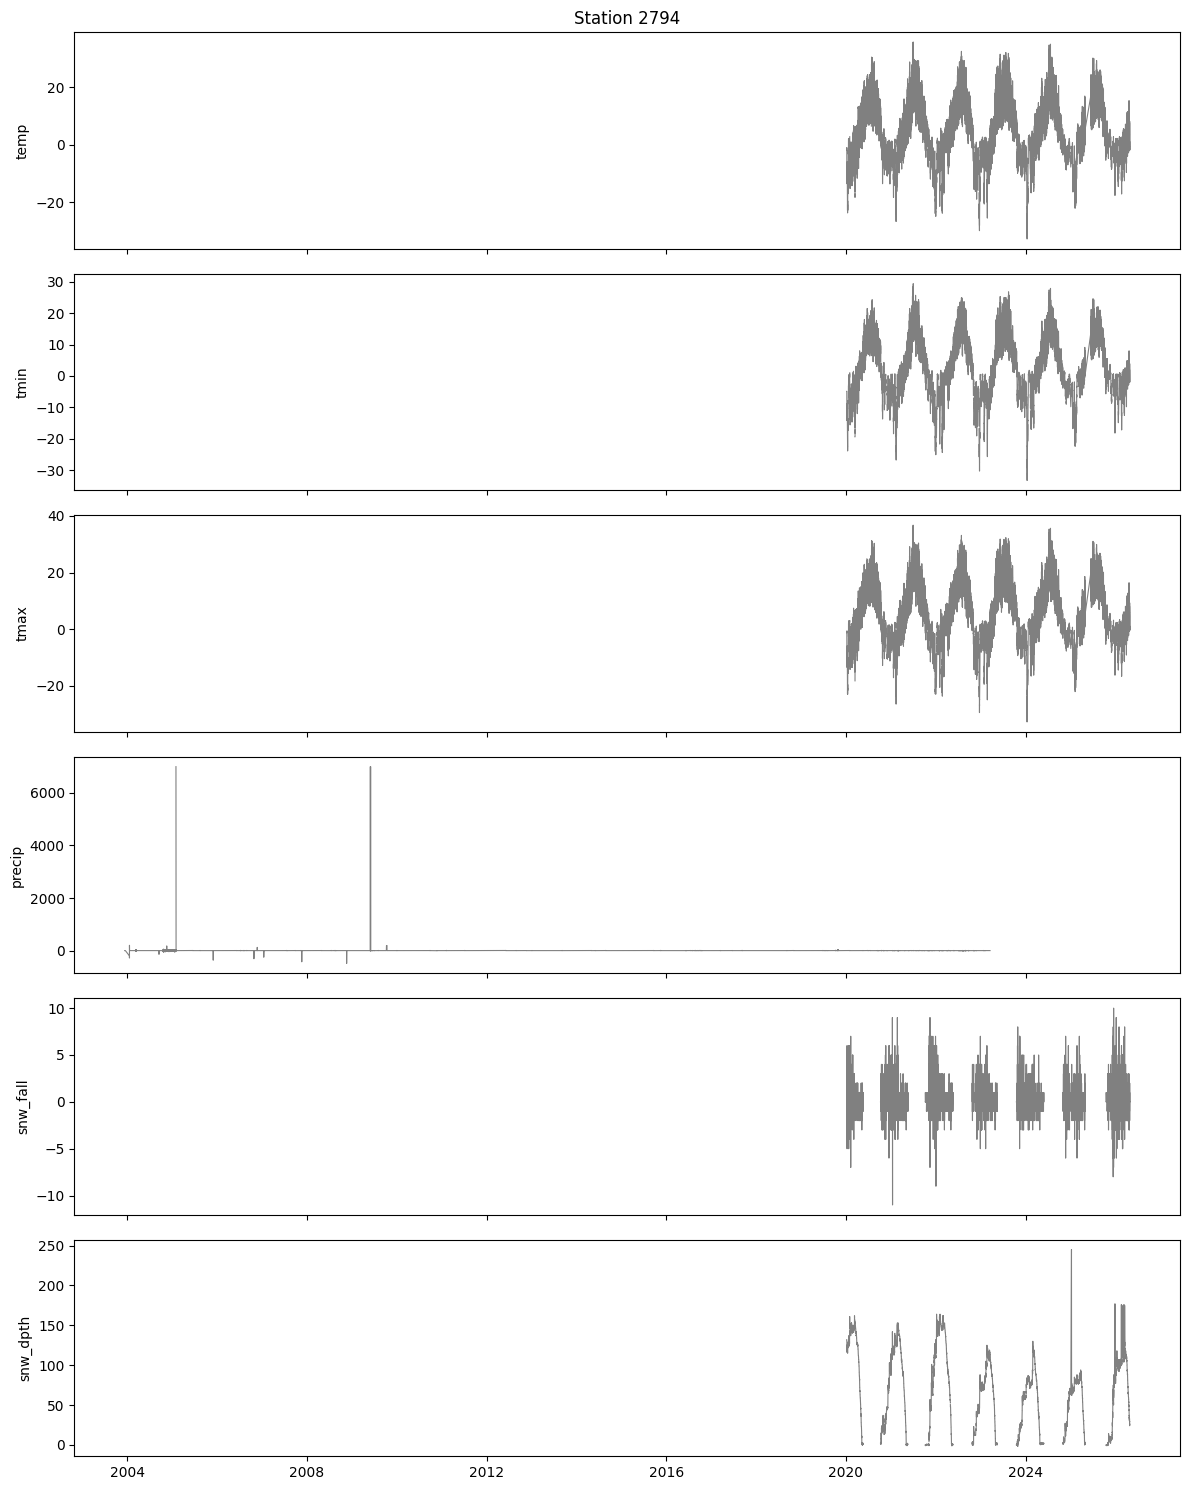

In [318]:
stat_id = 1
station_df = df_sql_list[stat_id][1]

station_df = station_df[[
    'temp',
    'tmin',
    'tmax',
    'precip',
    'snw_fall',
    'snw_dpth'
]]

start_time = station_df.apply(lambda col: col.first_valid_index()).min()

station_df_trim = station_df.loc[start_time:]

plot_weather_data(station_df_trim, title=f"Station {station_id}")

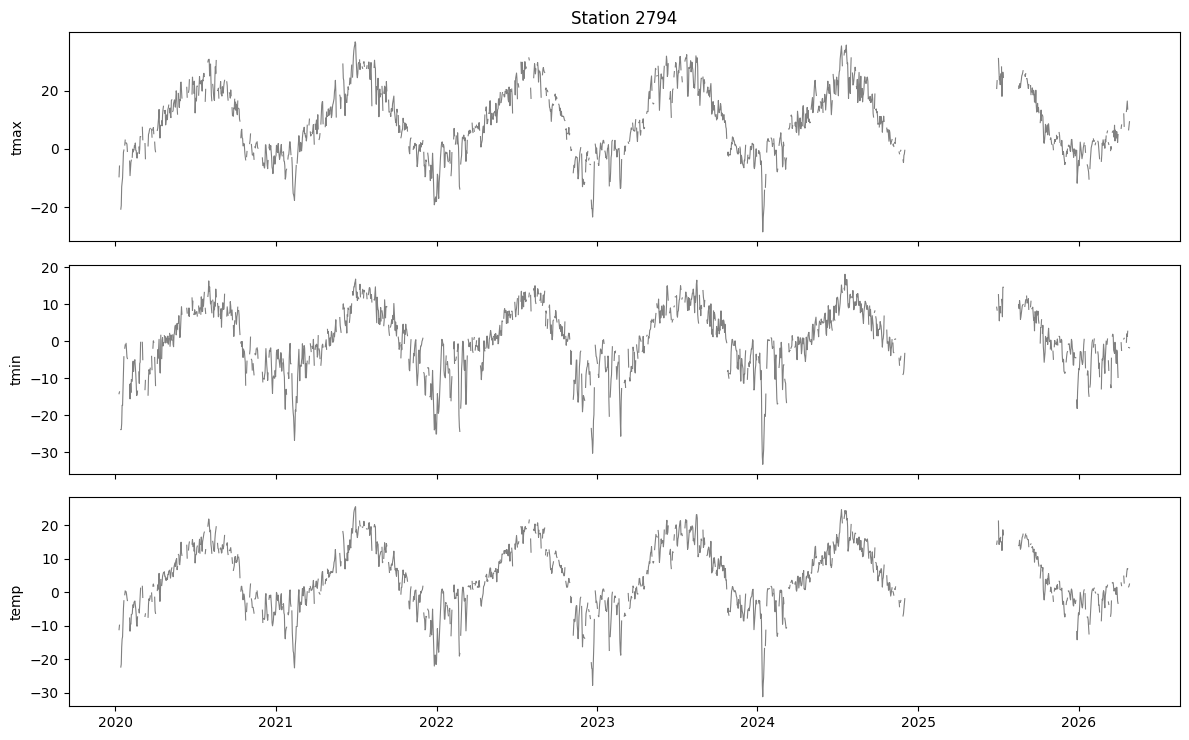

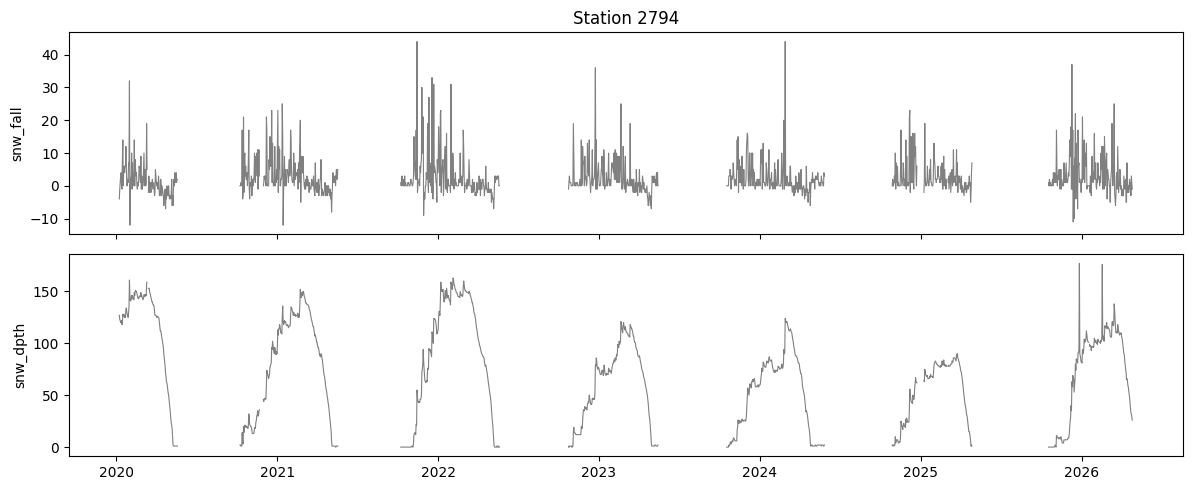

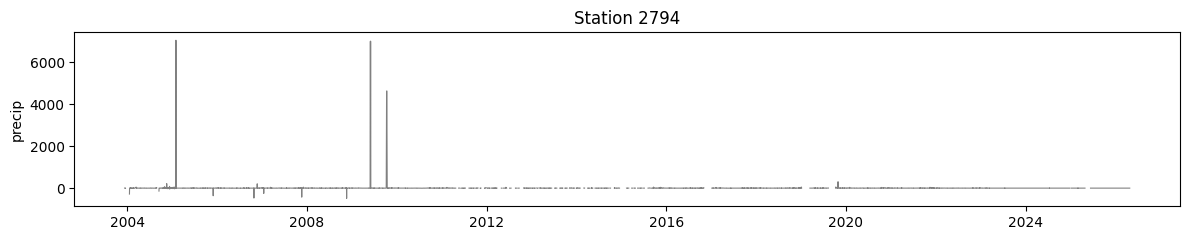

net_var_name,tmax,tmin,temp,snw_fall,snw_dpth,precip
obs_time,,,,,,
2003-12-11,NaN,NaN,NaN,NaN,NaN,0.6
2003-12-12,NaN,NaN,NaN,NaN,NaN,3.0
2003-12-13,NaN,NaN,NaN,NaN,NaN,4.1
2003-12-14,NaN,NaN,NaN,NaN,NaN,2.0
2003-12-15,NaN,NaN,NaN,NaN,NaN,0.7
...,...,...,...,...,...,...
2026-04-23,NaN,NaN,NaN,-3.0,33.0,0.0
2026-04-24,6.5,-1.7,1.579167,3.0,32.0,0.0
2026-04-25,8.1,-1.7,1.879167,1.0,29.0,0.0


In [319]:
import numpy as np


def hourly_to_daily(df, cols, agg_map, min_hours):
    """
    Convert hourly data to daily with validity filtering.

    df        : DataFrame with datetime index
    cols      : columns to check for validity
    agg_map   : dict of aggregation rules
    min_hours : minimum valid hourly observations per day
                (int or dict per column)
    """

    df = df.sort_index()

    # --- count valid values per day ---
    valid_counts = (
        df.groupby(df.index.floor("D"))[cols]
        .apply(lambda x: x.notna().sum())
    )

    # --- build validity mask ---
    if isinstance(min_hours, dict):
        valid_days = np.ones(len(valid_counts), dtype=bool)
        for c in cols:
            valid_days &= valid_counts[c] >= min_hours.get(c, 0)
        valid_days = pd.Series(valid_days, index=valid_counts.index)
    else:
        valid_days = valid_counts.ge(min_hours).all(axis=1)

    # --- aggregate ---
    daily = df.resample("1D").agg(agg_map)

    # --- apply mask ---
    daily = daily.where(valid_days)

    return daily


daily_tas = hourly_to_daily(
    station_df_trim,
    cols=["tmax", "tmin", "temp"],
    agg_map={
        "tmax": "max",
        "tmin": "min",
        "temp": "mean",
    },
    min_hours=24
)

plot_weather_data(daily_tas, title=f"Station {station_id}")

daily_sn = hourly_to_daily(
    station_df_trim,
    cols=["snw_fall", "snw_dpth"],
    agg_map={
        "snw_fall": "sum",
        "snw_dpth": "last",   # usually better than mean
    },
    min_hours=10
)

plot_weather_data(daily_sn, title=f"Station {station_id}")


daily_precip = hourly_to_daily(
    station_df_trim,
    cols=["precip"],
    agg_map={"precip": "sum"},
    min_hours=0   # or 24 if strict
)

plot_weather_data(daily_precip, title=f"Station {station_id}")

daily_all = pd.concat(
    [daily_tas, daily_sn, daily_precip],
    axis=1
)
daily_all

In [320]:
import pandas as pd
import numpy as np


def qc_temperature_consistency(
    df,
    tmax_col="tmax",
    tmin_col="tmin",
    tobs_col="temp",
    spike_threshold=25,
    lag_threshold=40
):
    """
    Internal consistency QC for temperature observations.

    QC logic:
    ----------
    0 = missing
    1 = good
    2 = suspect (spike or lag inconsistency)
    3 = bad (physical inconsistency)

    Returns
    -------
    result : pd.DataFrame
        Original data + QC flags + qc_label + qc_code
    """

    df = df.sort_index().copy()

    # ------------------------------------------------------------
    # 1. Extract variables
    # ------------------------------------------------------------
    TMAX = df[tmax_col]
    TMIN = df[tmin_col]
    TOBS = df[tobs_col]

    # ------------------------------------------------------------
    # 2. Missing mask
    # (all variables missing)
    # ------------------------------------------------------------
    missing = TMAX.isna() & TMIN.isna() & TOBS.isna()

    # ------------------------------------------------------------
    # 3. Basic physical consistency
    # TMAX >= TOBS >= TMIN
    # ------------------------------------------------------------
    flag_basic = ~((TMAX >= TMIN) & (TMAX >= TOBS) & (TOBS >= TMIN))
    flag_basic = flag_basic & ~missing

    # ------------------------------------------------------------
    # 4. Spike / dip check
    # ------------------------------------------------------------
    flag_spike = (
        ((TMAX - TMAX.shift(1)).abs() > spike_threshold) |
        ((TMIN - TMIN.shift(1)).abs() > spike_threshold) |
        ((TOBS - TOBS.shift(1)).abs() > spike_threshold)
    )
    flag_spike = flag_spike & ~missing

    # ------------------------------------------------------------
    # 5. Lagged consistency
    # ------------------------------------------------------------
    tmax_prev_max = pd.concat(
        [TMIN.shift(1), TOBS.shift(1)], axis=1
    ).max(axis=1)

    tmin_prev_min = pd.concat(
        [TMAX.shift(1), TOBS.shift(1)], axis=1
    ).min(axis=1)

    flag_lag = (
        (TMAX < (tmax_prev_max - lag_threshold)) |
        (TMIN > (tmin_prev_min + lag_threshold))
    )
    flag_lag = flag_lag & ~missing

    # ------------------------------------------------------------
    # 6. Combine flags
    # ------------------------------------------------------------
    qc_flags = pd.DataFrame({
        "flag_missing": missing,
        "flag_basic": flag_basic,
        "flag_spike": flag_spike,
        "flag_lag": flag_lag
    }, index=df.index)

    qc_flags["flag_any"] = (
        qc_flags[["flag_basic", "flag_spike", "flag_lag"]]
        .any(axis=1)
    )

    # ------------------------------------------------------------
    # 7. QC label (human readable)
    # ------------------------------------------------------------
    qc_flags["qc_label"] = "good"

    qc_flags.loc[qc_flags["flag_missing"], "qc_label"] = "missing"

    qc_flags.loc[qc_flags["flag_basic"], "qc_label"] = "bad"

    qc_flags.loc[
        (~qc_flags["flag_missing"]) &
        (~qc_flags["flag_basic"]) &
        (qc_flags["flag_spike"] | qc_flags["flag_lag"]),
        "qc_label"
    ] = "suspect"

    # ------------------------------------------------------------
    # 8. QC code (numeric)
    # ------------------------------------------------------------
    qc_flags["qc_code"] = 1  # good

    qc_flags.loc[qc_flags["flag_missing"], "qc_code"] = 0
    qc_flags.loc[qc_flags["flag_basic"], "qc_code"] = 3
    qc_flags.loc[
        (~qc_flags["flag_missing"]) &
        (~qc_flags["flag_basic"]) &
        (qc_flags["flag_spike"] | qc_flags["flag_lag"]),
        "qc_code"
    ] = 2

    # ------------------------------------------------------------
    # 9. Merge back to data
    # ------------------------------------------------------------
    result = df.join(qc_flags)

    return result


qc_tas_df = qc_temperature_consistency(daily_all)
qc_tas_df

,tmax,tmin,temp,snw_fall,snw_dpth,precip,flag_missing,flag_basic,flag_spike,flag_lag,flag_any,qc_label,qc_code
obs_time,,,,,,,,,,,,,
2003-12-11,NaN,NaN,NaN,NaN,NaN,0.6,True,False,False,False,False,missing,0
2003-12-12,NaN,NaN,NaN,NaN,NaN,3.0,True,False,False,False,False,missing,0
2003-12-13,NaN,NaN,NaN,NaN,NaN,4.1,True,False,False,False,False,missing,0
2003-12-14,NaN,NaN,NaN,NaN,NaN,2.0,True,False,False,False,False,missing,0
2003-12-15,NaN,NaN,NaN,NaN,NaN,0.7,True,False,False,False,False,missing,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23,NaN,NaN,NaN,-3.0,33.0,0.0,True,False,False,False,False,missing,0
2026-04-24,6.5,-1.7,1.579167,3.0,32.0,0.0,False,False,False,False,False,good,1
2026-04-25,8.1,-1.7,1.879167,1.0,29.0,0.0,False,False,False,False,False,good,1


### Temperature

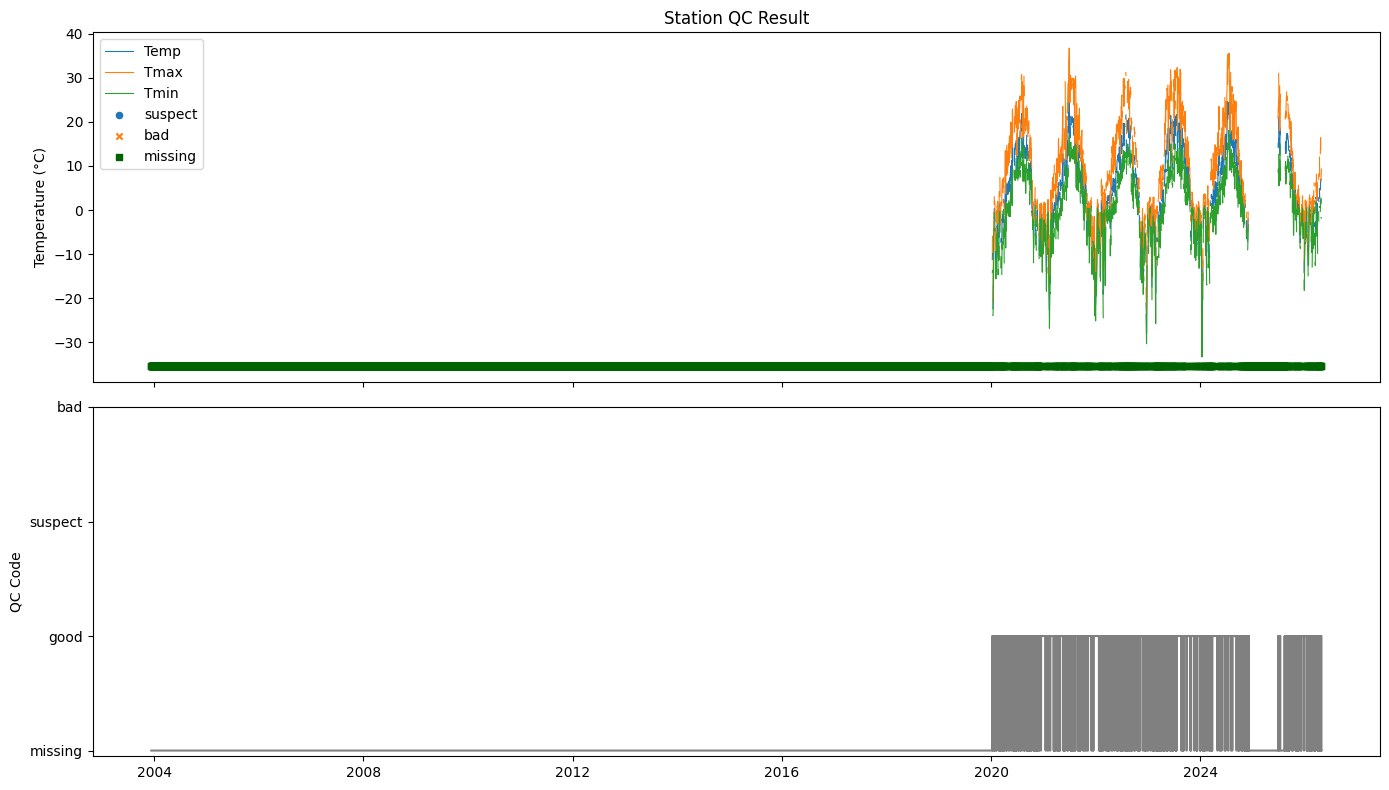

In [321]:
import matplotlib.pyplot as plt


def plot_qc_timeseries(df, title="QC Temperature Check"):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # ----------------------------
    # TOP: temperature time series
    # ----------------------------
    axes[0].plot(df.index, df["temp"], label="Temp", lw=0.8)
    axes[0].plot(df.index, df["tmax"], lw=0.8, label="Tmax")
    axes[0].plot(df.index, df["tmin"], lw=0.8, label="Tmin")

    axes[0].set_ylabel("Temperature (°C)")
    axes[0].set_title(title)
    axes[0].legend()

    # ----------------------------
    # overlay QC flags
    # ----------------------------
    for label, marker in zip(
        ["suspect", "bad"],
        ["o", "x"]
    ):
        subset = df[df["qc_label"] == label]
        axes[0].scatter(
            subset.index,
            subset["temp"],
            label=label,
            marker=marker,
            s=20
        )

    ymin = df[["tmin", "temp", "tmax"]].min().min()

    subset = df[df["qc_label"] == "missing"]

    axes[0].scatter(
        subset.index,
        [ymin - 2] * len(subset),   # push below data
        marker="s",
        s=20,
        color='darkgreen',
        label="missing"
    )

    axes[0].legend()

    # ----------------------------
    # BOTTOM: QC state timeline
    # ----------------------------
    axes[1].plot(df.index, df["qc_code"], drawstyle="steps-mid", color='gray')
    axes[1].set_ylabel("QC Code")
    axes[1].set_yticks([0, 1, 2, 3])
    axes[1].set_yticklabels(["missing", "good", "suspect", "bad"])

    plt.tight_layout()
    plt.show()


plot_qc_timeseries(qc_tas_df, title="Station QC Result")

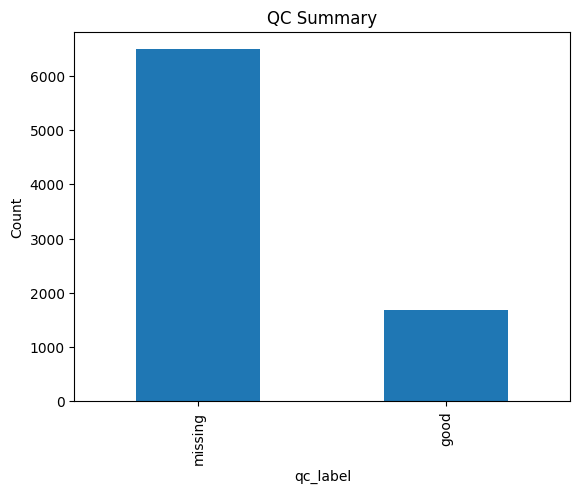

In [322]:
def plot_qc_summary(df):
    counts = df["qc_label"].value_counts()

    counts.plot(kind="bar")
    plt.ylabel("Count")
    plt.title("QC Summary")
    plt.show()


plot_qc_summary(qc_tas_df)

#### Snow only

In [323]:
import pandas as pd


def qc_snow_only(df, snow_col="snw_fall", snwd_col="snw_dpth"):
    df = df.copy()

    SNOW = df[snow_col]
    SNWD = df[snwd_col]

    SNOW_prev = SNOW.shift(1)
    SNOW_next = SNOW.shift(-1)
    SNWD_prev = SNWD.shift(1)

    snwd_change = SNWD - SNWD_prev

    # -------------------------------------------------
    # 1. validity masks (THIS is the key improvement)
    # -------------------------------------------------
    valid_prev = SNOW.notna() & SNOW_prev.notna() & SNWD.notna() & SNWD_prev.notna()
    valid_next = SNOW.notna() & SNOW_next.notna() & SNWD.notna() & SNWD_prev.notna()

    valid_any = valid_prev | valid_next

    # -------------------------------------------------
    # 2. conditions (only computed where valid)
    # -------------------------------------------------
    cond_prev = snwd_change > (SNOW + SNOW_prev + 25)
    cond_next = snwd_change > (SNOW + SNOW_next + 25)

    flag_raw = cond_prev | cond_next

    # -------------------------------------------------
    # 3. final flag WITH explicit missing
    # -------------------------------------------------
    flag = flag_raw.where(valid_any, pd.NA)

    # -------------------------------------------------
    # 4. output
    # -------------------------------------------------
    flags = pd.DataFrame(index=df.index)

    flags["flag_snow_snwd"] = flag

    # keep consistency
    flags["flag_snow"] = flag
    flags["flag_snwd"] = flag

    # shift preserves NA automatically
    flags["flag_snwd_prev"] = flag.shift(-1)

    # optional: explicitly mark missing source data
    flags["flag_missing_input"] = (~valid_any).astype("Int64")

    return flags


snow_qc = qc_snow_only(daily_all)
snow_qc

,flag_snow_snwd,flag_snow,flag_snwd,flag_snwd_prev,flag_missing_input
obs_time,,,,,
2003-12-11,<NA>,<NA>,<NA>,<NA>,1
2003-12-12,<NA>,<NA>,<NA>,<NA>,1
2003-12-13,<NA>,<NA>,<NA>,<NA>,1
2003-12-14,<NA>,<NA>,<NA>,<NA>,1
2003-12-15,<NA>,<NA>,<NA>,<NA>,1
...,...,...,...,...,...
2026-04-23,False,False,False,False,0
2026-04-24,False,False,False,False,0
2026-04-25,False,False,False,False,0


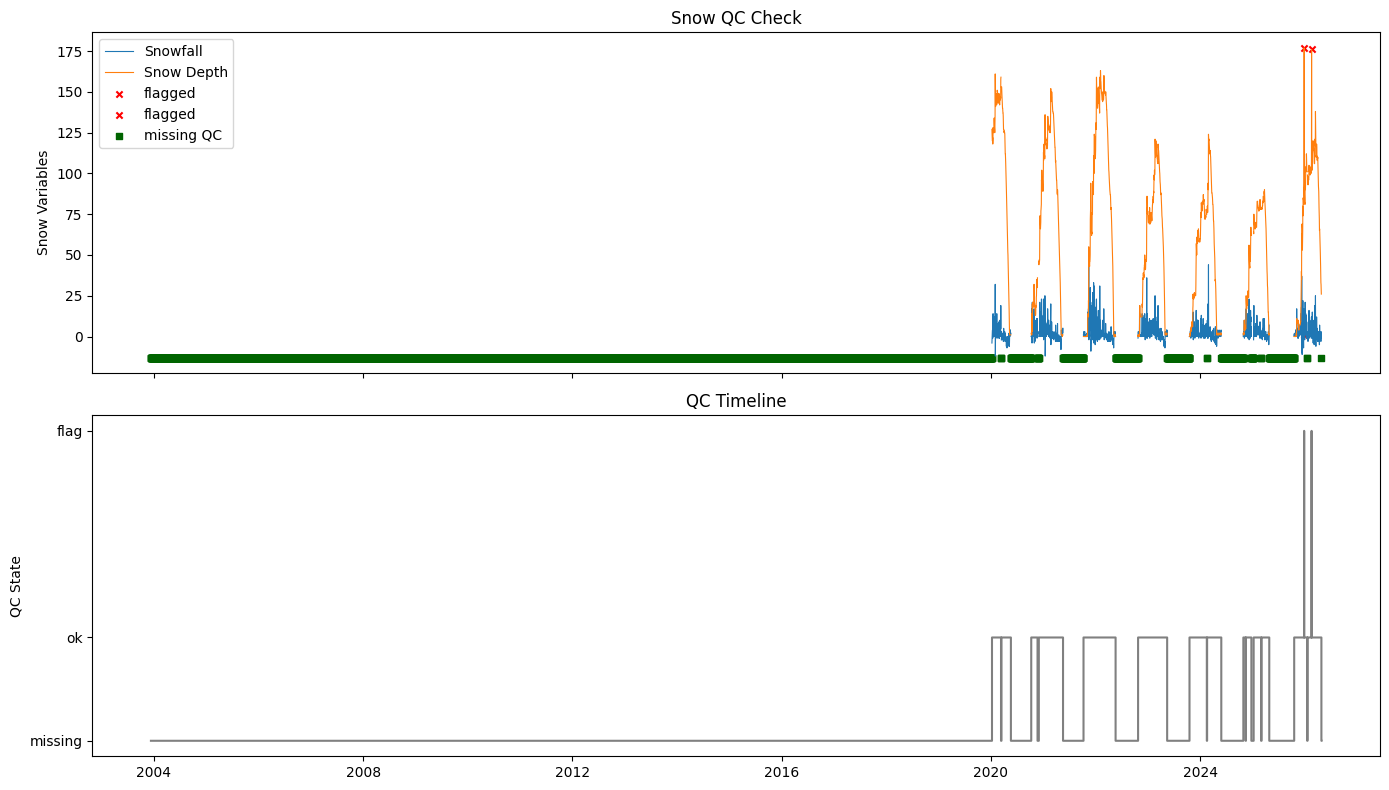

In [324]:
import numpy as np
import matplotlib.pyplot as plt


def plot_snow_qc_timeseries(df, snow_qc, title="Snow QC Check"):

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --------------------------------------------------
    # TOP: physical variables
    # --------------------------------------------------
    axes[0].plot(df.index, df["snw_fall"], label="Snowfall", lw=0.8)
    axes[0].plot(df.index, df["snw_dpth"], label="Snow Depth", lw=0.8)

    axes[0].set_ylabel("Snow Variables")
    axes[0].set_title(title)
    axes[0].legend()

    # --------------------------------------------------
    # overlay QC flags (like your temp plot style)
    # --------------------------------------------------
    flag_col = snow_qc["flag_snow"].copy()

    # True = 1, False = 0, NA = missing
    flag_num = flag_col.map({True: 1, False: 0})

    # flagged points
    flagged = flag_num == 1
    axes[0].scatter(
        df.index[flagged],
        df.loc[flagged, "snw_fall"],
        marker="x",
        s=20,
        color="red",
        label="flagged"
    )
    flagged = flag_num == 1
    axes[0].scatter(
        df.index[flagged],
        df.loc[flagged, "snw_dpth"],
        marker="x",
        s=20,
        color="red",
        label="flagged"
    )
    # missing QC evaluation
    missing = flag_col.isna()
    if missing.any():
        ymin = np.nanmin(df[["snw_fall", "snw_dpth"]].values)

        axes[0].scatter(
            df.index[missing],
            [ymin - 1] * missing.sum(),
            marker="s",
            s=20,
            color="darkgreen",
            label="missing QC"
        )

    axes[0].legend()

    # --------------------------------------------------
    # BOTTOM: QC timeline (step plot)
    # --------------------------------------------------
    axes[1].plot(
        df.index,
        flag_num.fillna(-0.5),   # -0.5 = missing
        drawstyle="steps-mid",
        color='gray'
    )

    axes[1].set_ylabel("QC State")
    axes[1].set_yticks([-0.5, 0, 1])
    axes[1].set_yticklabels(["missing", "ok", "flag"])
    axes[1].set_title("QC Timeline")

    plt.tight_layout()
    plt.show()


plot_snow_qc_timeseries(daily_all, snow_qc)

#### Snow and temperature

In [325]:
import pandas as pd


def qc_snow_temp(df,
                 snow_col="snw_fall",
                 snwd_col="snw_dpth",
                 tmin_col="tmin"):

    df = df.copy()

    SNOW = df[snow_col]
    SNWD = df[snwd_col]
    TMIN = df[tmin_col]

    TMIN_prev = TMIN.shift(1)
    TMIN_next = TMIN.shift(-1)
    SNWD_prev = SNWD.shift(1)

    # -------------------------------------------------
    # derived variables
    # -------------------------------------------------
    tmin_min = pd.concat([TMIN_prev, TMIN_next], axis=1).min(axis=1)
    snwd_change = SNWD - SNWD_prev

    # -------------------------------------------------
    # 1. validity masks (like your snow_only function)
    # -------------------------------------------------
    valid_snow = SNOW.notna() & TMIN_prev.notna() & TMIN_next.notna()
    valid_snwd = SNWD.notna() & SNWD_prev.notna(
    ) & TMIN_prev.notna() & TMIN_next.notna()

    # -------------------------------------------------
    # 2. conditions (compute everywhere first)
    # -------------------------------------------------
    cond_snow = (SNOW > 0) & (tmin_min >= 7)
    cond_snwd = (snwd_change > 0) & (tmin_min >= 7)

    # -------------------------------------------------
    # 3. apply validity → explicit NA
    # -------------------------------------------------
    flag_snow_warm = cond_snow.where(valid_snow, pd.NA)
    flag_snwd_warm = cond_snwd.where(valid_snwd, pd.NA)

    # -------------------------------------------------
    # 4. output
    # -------------------------------------------------
    flags = pd.DataFrame(index=df.index)

    flags["flag_snow_warm"] = flag_snow_warm
    flags["flag_snwd_warm"] = flag_snwd_warm

    # propagate to previous day (consistent with your design)
    flags["flag_snwd_warm_prev"] = flag_snwd_warm.shift(-1)

    # -------------------------------------------------
    # 5. explicit missing indicators (VERY useful)
    # -------------------------------------------------
    flags["flag_missing_snow"] = (~valid_snow).astype("Int64")
    flags["flag_missing_snwd"] = (~valid_snwd).astype("Int64")

    # combined missing (optional but convenient)
    flags["flag_missing_any"] = ((~valid_snow) | (~valid_snwd)).astype("Int64")

    return flags


snow_temp_qc = qc_snow_temp(daily_all)

snow_temp_qc

,flag_snow_warm,flag_snwd_warm,flag_snwd_warm_prev,flag_missing_snow,flag_missing_snwd,flag_missing_any
obs_time,,,,,,
2003-12-11,<NA>,<NA>,<NA>,1,1,1
2003-12-12,<NA>,<NA>,<NA>,1,1,1
2003-12-13,<NA>,<NA>,<NA>,1,1,1
2003-12-14,<NA>,<NA>,<NA>,1,1,1
2003-12-15,<NA>,<NA>,<NA>,1,1,1
...,...,...,...,...,...,...
2026-04-23,False,False,<NA>,0,0,0
2026-04-24,<NA>,<NA>,False,1,1,1
2026-04-25,False,False,<NA>,0,0,0


In [326]:
snow_temp_qc['flag_snwd_warm'].sum()

0

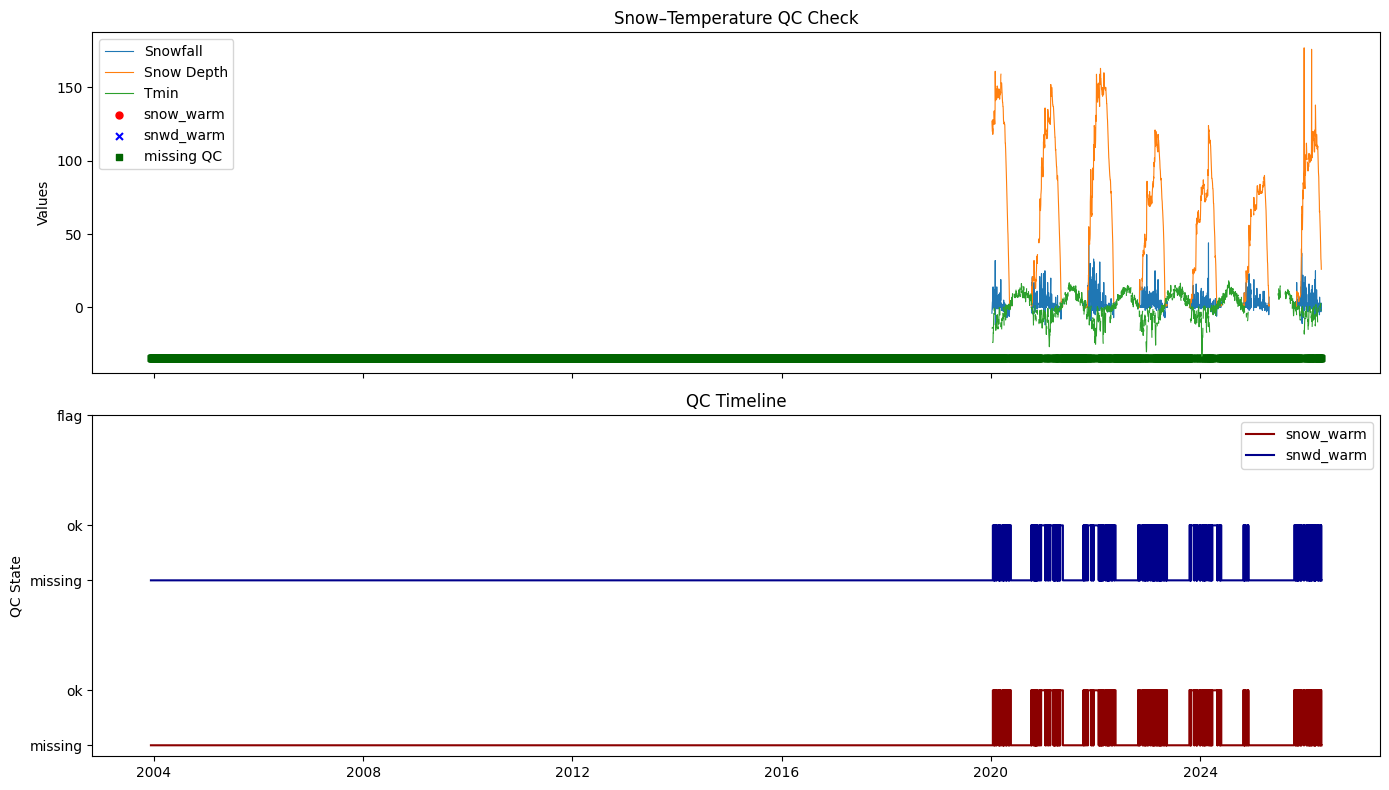

In [327]:
import numpy as np
import matplotlib.pyplot as plt


def plot_snow_temp_qc_timeseries(df, snow_temp_qc, title="Snow–Temperature QC Check"):

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --------------------------------------------------
    # TOP: physical variables
    # --------------------------------------------------
    axes[0].plot(df.index, df["snw_fall"], label="Snowfall", lw=0.8)
    axes[0].plot(df.index, df["snw_dpth"], label="Snow Depth", lw=0.8)
    axes[0].plot(df.index, df["tmin"], label="Tmin", lw=0.8)

    axes[0].set_ylabel("Values")
    axes[0].set_title(title)

    # --------------------------------------------------
    # QC flags
    # --------------------------------------------------
    snow_flag = snow_temp_qc["flag_snow_warm"]
    snwd_flag = snow_temp_qc["flag_snwd_warm"]

    snow_num = snow_flag.map({True: 1, False: 0})
    snwd_num = snwd_flag.map({True: 1, False: 0})

    # --- flagged points ---
    f_snow = snow_num == 1
    f_snwd = snwd_num == 1

    axes[0].scatter(
        df.index[f_snow],
        df.loc[f_snow, "snw_fall"],
        marker="o",
        s=25,
        color="red",
        label="snow_warm"
    )

    axes[0].scatter(
        df.index[f_snwd],
        df.loc[f_snwd, "snw_dpth"],
        marker="x",
        s=25,
        color="blue",
        label="snwd_warm"
    )

    # --------------------------------------------------
    # missing QC (important)
    # --------------------------------------------------
    missing = snow_flag.isna() | snwd_flag.isna()

    if missing.any():
        ymin = np.nanmin(df[["snw_fall", "snw_dpth", "tmin"]].values)

        axes[0].scatter(
            df.index[missing],
            [ymin - 1] * missing.sum(),
            marker="s",
            s=20,
            color="darkgreen",
            label="missing QC"
        )

    axes[0].legend()

    # --------------------------------------------------
    # BOTTOM: QC timeline (two-layer encoding)
    # --------------------------------------------------
    axes[1].plot(
        df.index,
        snow_num.fillna(-0.5),
        drawstyle="steps-mid",
        color="darkred",
        label="snow_warm"
    )

    axes[1].plot(
        df.index,
        snwd_num.fillna(-0.5) + 1.5,
        drawstyle="steps-mid",
        color="darkblue",
        label="snwd_warm"
    )

    axes[1].set_ylabel("QC State")
    axes[1].set_yticks([-0.5, 0, 1, 1.5, 2.5])
    axes[1].set_yticklabels(["missing", "ok", "missing", "ok", "flag"])
    axes[1].set_title("QC Timeline")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_snow_temp_qc_timeseries(daily_all, snow_temp_qc)

In [328]:
snow_temp_qc

,flag_snow_warm,flag_snwd_warm,flag_snwd_warm_prev,flag_missing_snow,flag_missing_snwd,flag_missing_any
obs_time,,,,,,
2003-12-11,<NA>,<NA>,<NA>,1,1,1
2003-12-12,<NA>,<NA>,<NA>,1,1,1
2003-12-13,<NA>,<NA>,<NA>,1,1,1
2003-12-14,<NA>,<NA>,<NA>,1,1,1
2003-12-15,<NA>,<NA>,<NA>,1,1,1
...,...,...,...,...,...,...
2026-04-23,False,False,<NA>,0,0,0
2026-04-24,<NA>,<NA>,False,1,1,1
2026-04-25,False,False,<NA>,0,0,0


#### Snow and precipitation

In [329]:
import pandas as pd


def qc_snow_precip(df,
                   snow_col="snw_fall",
                   snwd_col="snw_dpth",
                   prcp_col="precip"):

    df = df.copy()

    SNOW = df[snow_col]
    SNWD = df[snwd_col]
    PRCP = df[prcp_col]

    SNOW_prev = SNOW.shift(1)
    SNOW_next = SNOW.shift(-1)

    SNWD_prev = SNWD.shift(1)
    snwd_change = SNWD - SNWD_prev

    PRCP_prev = PRCP.shift(1)
    PRCP_next = PRCP.shift(-1)

    prcp_window_max = pd.concat(
        [PRCP_prev, PRCP, PRCP_next], axis=1
    ).max(axis=1)

    # -------------------------------------------------
    # 1. validity masks (STRICT like other functions)
    # -------------------------------------------------
    valid_snow = SNOW.notna()
    valid_prcp = PRCP.notna() & PRCP_prev.notna() & PRCP_next.notna()
    valid_snwd = SNWD.notna() & SNWD_prev.notna()

    # combine per-variable validity
    valid_snow_prcp = valid_snow & valid_prcp
    valid_snwd_prcp = valid_snwd & valid_prcp

    # -------------------------------------------------
    # 2. conditions (compute everywhere first)
    # -------------------------------------------------
    cond_snow_no_prcp = (SNOW >= 100) & (prcp_window_max == 0)

    cond_prev = SNOW >= 100 * (PRCP + PRCP_prev)
    cond_next = SNOW >= 100 * (PRCP + PRCP_next)

    cond_snow_ratio = (SNOW >= 200) & (cond_prev | cond_next)

    cond_snwd_no_prcp = (snwd_change >= 100) & (prcp_window_max == 0)

    cond_prev_snwd = snwd_change >= 100 * (PRCP + PRCP_prev)
    cond_next_snwd = snwd_change >= 100 * (PRCP + PRCP_next)

    cond_snwd_ratio = (snwd_change >= 200) & (cond_prev_snwd & cond_next_snwd)

    # -------------------------------------------------
    # 3. apply validity → explicit NA
    # -------------------------------------------------
    flag_snow_no_prcp = cond_snow_no_prcp.where(valid_snow_prcp, pd.NA)
    flag_snow_prcp_ratio = cond_snow_ratio.where(valid_snow_prcp, pd.NA)

    flag_snwd_no_prcp = cond_snwd_no_prcp.where(valid_snwd_prcp, pd.NA)
    flag_snwd_prcp_ratio = cond_snwd_ratio.where(valid_snwd_prcp, pd.NA)

    # -------------------------------------------------
    # 4. combine flags (preserve NA properly)
    # -------------------------------------------------
    def combine_flags(*args):
        out = args[0]
        for a in args[1:]:
            out = out | a
        return out

    flag_snow = combine_flags(flag_snow_no_prcp, flag_snow_prcp_ratio)
    flag_snwd = combine_flags(flag_snwd_no_prcp, flag_snwd_prcp_ratio)
    flag_prcp = combine_flags(
        flag_snow_no_prcp,
        flag_snow_prcp_ratio,
        flag_snwd_no_prcp,
        flag_snwd_prcp_ratio
    )

    # -------------------------------------------------
    # 5. assemble output
    # -------------------------------------------------
    flags = pd.DataFrame(index=df.index)

    flags["flag_snow_no_prcp"] = flag_snow_no_prcp
    flags["flag_snow_prcp_ratio"] = flag_snow_prcp_ratio
    flags["flag_snwd_no_prcp"] = flag_snwd_no_prcp
    flags["flag_snwd_prcp_ratio"] = flag_snwd_prcp_ratio

    flags["flag_snow"] = flag_snow
    flags["flag_snwd"] = flag_snwd
    flags["flag_prcp"] = flag_prcp

    flags["flag_snwd_prev"] = flag_snwd.shift(-1)

    # -------------------------------------------------
    # 6. explicit missing indicators (NEW)
    # -------------------------------------------------
    flags["flag_missing_snow"] = (~valid_snow).astype("Int64")
    flags["flag_missing_prcp"] = (~valid_prcp).astype("Int64")
    flags["flag_missing_snwd"] = (~valid_snwd).astype("Int64")

    flags["flag_missing_any"] = (
        (~valid_snow) | (~valid_prcp) | (~valid_snwd)
    ).astype("Int64")

    return flags


snow_precip_qc = qc_snow_precip(daily_all)
snow_precip_qc

,flag_snow_no_prcp,flag_snow_prcp_ratio,flag_snwd_no_prcp,flag_snwd_prcp_ratio,flag_snow,flag_snwd,flag_prcp,flag_snwd_prev,flag_missing_snow,flag_missing_prcp,flag_missing_snwd,flag_missing_any
obs_time,,,,,,,,,,,,
2003-12-11,<NA>,<NA>,<NA>,<NA>,False,False,False,False,1,1,1,1
2003-12-12,<NA>,<NA>,<NA>,<NA>,False,False,False,False,1,0,1,1
2003-12-13,<NA>,<NA>,<NA>,<NA>,False,False,False,False,1,0,1,1
2003-12-14,<NA>,<NA>,<NA>,<NA>,False,False,False,False,1,0,1,1
2003-12-15,<NA>,<NA>,<NA>,<NA>,False,False,False,False,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23,False,False,False,False,False,False,False,False,0,0,0,0
2026-04-24,False,False,False,False,False,False,False,False,0,0,0,0
2026-04-25,False,False,False,False,False,False,False,False,0,0,0,0


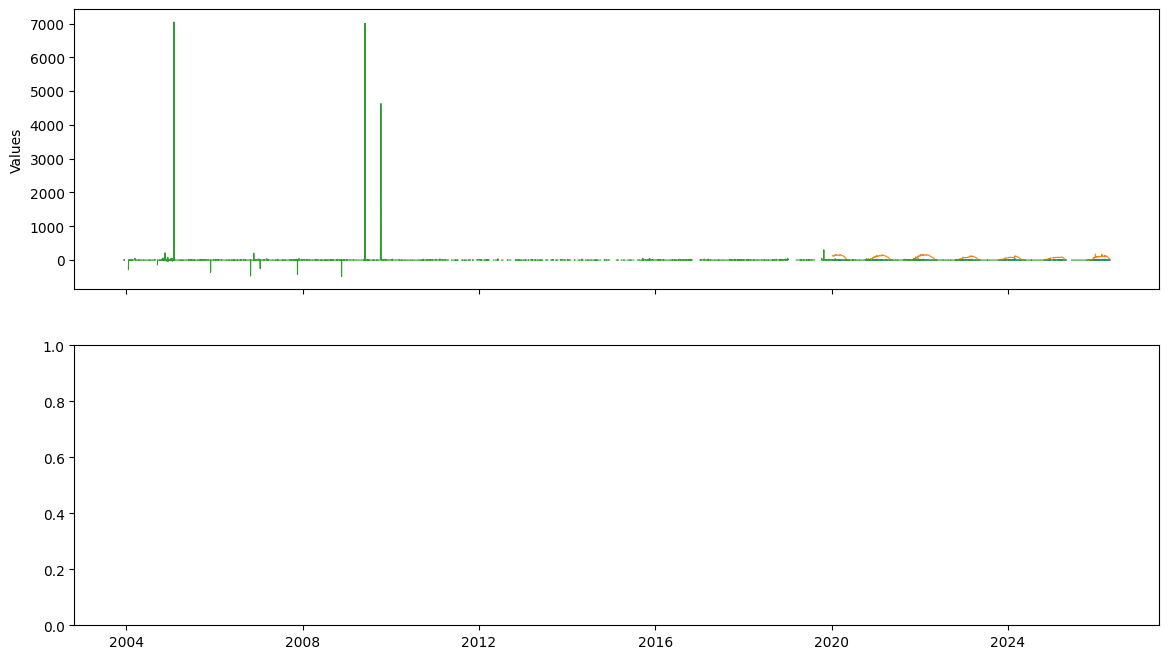

In [330]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --------------------------------------------------
# TOP: physical variables
# --------------------------------------------------
axes[0].plot(daily_all.index, daily_all["snw_fall"], label="Snowfall", lw=0.8)
axes[0].plot(daily_all.index, daily_all["snw_dpth"],
             label="Snow Depth", lw=0.8)
axes[0].plot(daily_all.index, daily_all["precip"], label="Precip", lw=0.8)

axes[0].set_ylabel("Values")
# axes[0].set_title(title)

plt.show()

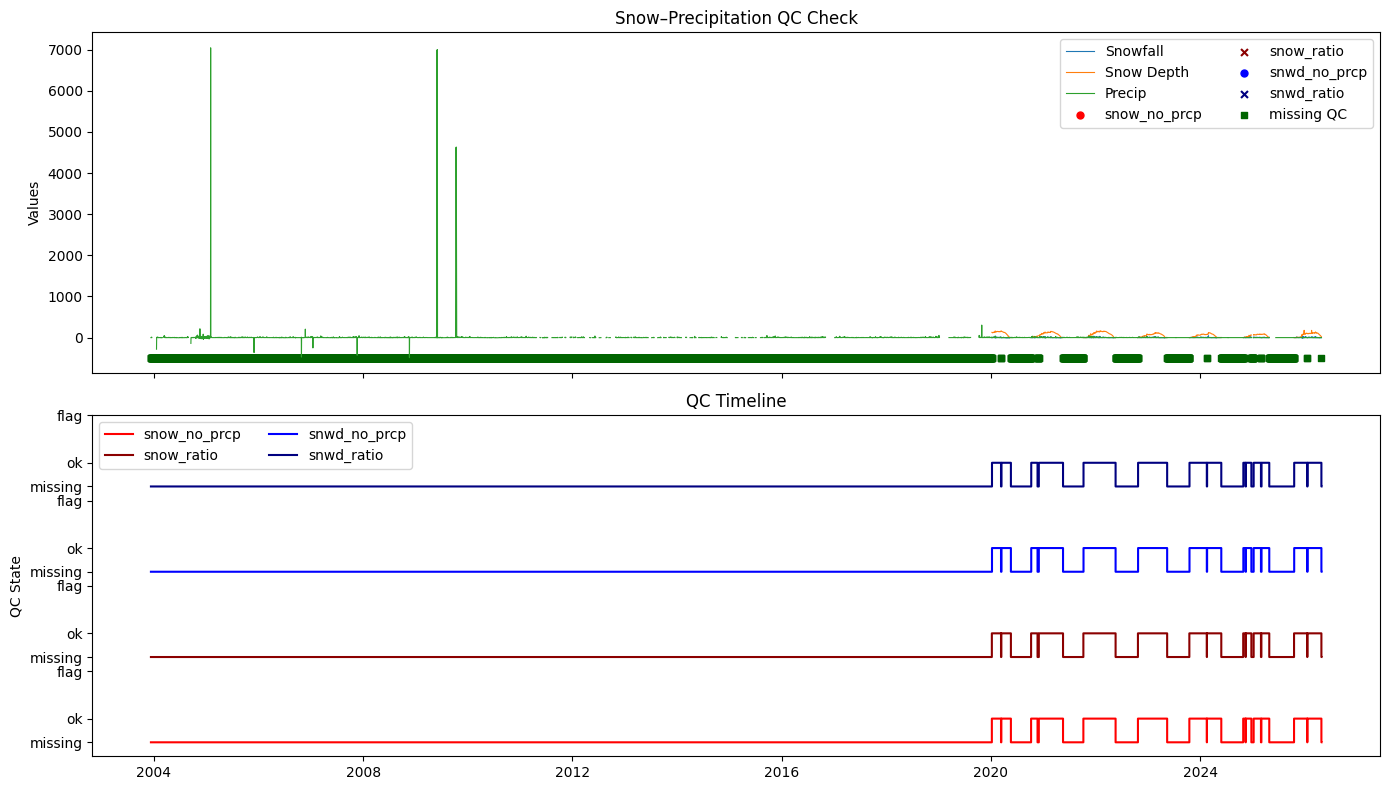

In [331]:
import numpy as np
import matplotlib.pyplot as plt


def plot_snow_precip_qc_timeseries(df, snow_precip_qc,
                                   title="Snow–Precipitation QC Check"):

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --------------------------------------------------
    # TOP: physical variables
    # --------------------------------------------------
    axes[0].plot(df.index, df["snw_fall"], label="Snowfall", lw=0.8)
    axes[0].plot(df.index, df["snw_dpth"], label="Snow Depth", lw=0.8)
    axes[0].plot(df.index, df["precip"], label="Precip", lw=0.8)

    axes[0].set_ylabel("Values")
    axes[0].set_title(title)

    # --------------------------------------------------
    # helper: convert flag → numeric safely
    # --------------------------------------------------
    def to_num(flag):
        return flag.map({True: 1, False: 0})

    # --------------------------------------------------
    # flag groups
    # --------------------------------------------------
    flag_groups = [
        ("flag_snow_no_prcp", "o", "red", "snow_no_prcp", "snw_fall"),
        ("flag_snow_prcp_ratio", "x", "darkred", "snow_ratio", "snw_fall"),
        ("flag_snwd_no_prcp", "o", "blue", "snwd_no_prcp", "snw_dpth"),
        ("flag_snwd_prcp_ratio", "x", "navy", "snwd_ratio", "snw_dpth"),
    ]

    # --------------------------------------------------
    # plot flagged points
    # --------------------------------------------------
    for col, marker, color, label, var in flag_groups:
        flag = to_num(snow_precip_qc[col])
        f = flag == 1

        axes[0].scatter(
            df.index[f],
            df.loc[f, var],
            marker=marker,
            s=25,
            color=color,
            label=label
        )

    # --------------------------------------------------
    # missing QC
    # --------------------------------------------------
    missing = snow_precip_qc["flag_missing_any"] == 1

    if missing.any():
        ymin = np.nanmin(df[["snw_fall", "snw_dpth", "precip"]].values)

        axes[0].scatter(
            df.index[missing],
            [ymin - 1] * missing.sum(),
            marker="s",
            s=20,
            color="darkgreen",
            label="missing QC"
        )

    axes[0].legend(ncol=2)

    # --------------------------------------------------
    # BOTTOM: QC timeline (stacked)
    # --------------------------------------------------
    y_offset = 0
    yticks = []
    ylabels = []

    for col, _, color, label, _ in flag_groups:
        flag = to_num(snow_precip_qc[col])

        y = flag.fillna(-0.5) + y_offset

        axes[1].plot(
            df.index,
            y,
            drawstyle="steps-mid",
            color=color,
            label=label
        )

        yticks.extend([y_offset - 0.5, y_offset, y_offset + 1])
        ylabels.extend(["missing", "ok", "flag"])

        y_offset += 1.8

    axes[1].set_ylabel("QC State")
    axes[1].set_yticks(yticks)
    axes[1].set_yticklabels(ylabels)
    axes[1].set_title("QC Timeline")
    axes[1].legend(ncol=2)

    plt.tight_layout()
    plt.show()


plot_snow_precip_qc_timeseries(daily_all, snow_precip_qc)

In [332]:
import pandas as pd


def summarize_qc(flags, main_flag_col):
    """
    flags: dataframe of QC flags
    main_flag_col: e.g. 'flag_snow', 'flag_snow_warm', etc.
    """

    flag = flags[main_flag_col]

    summary = {
        "n_total": len(flag),
        "n_flagged": (flag == True).sum(),
        "n_ok": (flag == False).sum(),
        "n_missing": flag.isna().sum(),
    }

    return pd.Series(summary)


summary = pd.DataFrame({
    "snow_only": summarize_qc(snow_qc, "flag_snow"),
    "snow_temp": summarize_qc(snow_temp_qc, "flag_snow_warm"),
    "snow_precip": summarize_qc(snow_precip_qc, "flag_snow"),
}).T


summary

,n_total,n_flagged,n_ok,n_missing
snow_only,8174,2,1335,6837
snow_temp,8174,0,836,7338
snow_precip,8174,0,8174,0
